# Fase 1: Etiquetado Semiautomático de Logs Web

Este notebook implementa la **fase de etiquetado inicial** de logs de acceso web usando un enfoque **semisupervisado**, combinando:

- **Isolation Forest** (detección de anomalías no supervisada)
- **Heurísticas basadas en firmas** (IoCs simples)

La lógica está inspirada directamente en el paper *Web Traffic Anomaly Detection Using Isolation Forest (2024)*.

> **Nota:** La columna `anomaly` del dataset original se ignora completamente.

dsdfsdf


## 1. Carga del dataset

In [62]:
import pandas as pd

df_master = pd.read_csv('../data/target/access_log_master_manual_labeling.csv')
df_master.head()

,ip_client,timestamp,status,size,user_agent,method,url,protocol,anomaly,status_category,...,url__count_percentage_symbol,url__count_question_symbol,url__count_hyphen,url__count_equal,url__url_length,url__digit_count,url__letter_count,url__count_special_characters,url__is_encoded,url__unusual_character_ratio
0,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2021/06/b2ap3_lar...,HTTP/2.0,0,200,...,0,0,2,0,74,10,52,12,0,0.094595
1,47.128.121.63,2025-11-25 00:00:16-05:00,200,675,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/plugins/elementor/assets/lib/font-...,HTTP/2.0,0,200,...,0,1,2,1,83,4,63,16,0,0.120482
2,47.128.121.63,2025-11-25 00:00:16-05:00,200,264,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/elementor/css/pos...,HTTP/2.0,0,200,...,0,1,2,1,70,15,43,12,0,0.128571
3,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2021/05/73192906_...,HTTP/2.0,0,200,...,0,0,2,0,96,57,26,13,0,0.072917
4,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2021/07/PNG-image...,HTTP/2.0,0,200,...,0,0,4,0,61,16,33,12,0,0.114754


In [69]:
df=df_master[df_master['anomaly']!=-1]
df['anomaly'].value_counts()


anomaly
0    492237
1     84530
Name: count, dtype: int64

In [71]:
df.to_csv(
    'access_logs_label_only.csv',
    index=False
)

In [72]:
from urllib.parse import unquote
from pandas import DataFrame

def engineer_isolation_forest_features(df:DataFrame):
  df_engineered=df.copy()
  # 2. CARACTERÍSTICAS DE FRECUENCIA/OCURRENCIA 
  print("Calculando características de frecuencia...")
  
  # a) URI Occurrences (frecuencia absoluta de cada URL)
  uri_counts = df_engineered['url'].value_counts().to_dict()
  df_engineered['uri_occurrence'] = df_engineered['url'].map(uri_counts)
  
  # b) User-Agent Occurrences (frecuencia absoluta de cada User-Agent)
  ua_counts = df_engineered['user_agent'].value_counts().to_dict()
  df_engineered['user_agent_occurrence'] = df_engineered['user_agent'].map(ua_counts)
  
  # c) IP Occurrences (frecuencia por IP)
  ip_counts = df_engineered['ip_client'].value_counts().to_dict()
  df_engineered['ip_occurrence'] = df_engineered['ip_client'].map(ip_counts)
  
  # 3. CARACTERÍSTICAS DE LONGITUD ()
  # a) URI Length
  df_engineered['uri_length'] = df_engineered['url'].str.len()
  
  # b) User-Agent Length
  df_engineered['user_agent_length'] = df_engineered['user_agent'].str.len()
  
  # c) Decoded URI Length (para URLs codificadas)
  df_engineered['uri_decoded_length'] = df_engineered['url'].apply(
      lambda x: len(unquote(x)) if isinstance(x, str) else 0
  )
  return df_engineered

## 2. Limpieza básica y selección de columnas

In [80]:
#df_expand=engineer_isolation_forest_features(df)
df_expand=engineer_isolation_forest_features(df_master)
cols = [
    'url__count_sql_words',
    'url__count_xss_words',
    'url__count_command_words',
    'url__count_malware_words',
    'url__count_obfuscation_code_words',
    'url__count_dir_words',
    'url__count_auth_words'
]

df_expand['ioc_ocurrence'] = df_expand[cols].sum(axis=1)

categorical_cols = ['method', 'protocol', 'status_category']
numeric_cols = [
    # Tamaño / estructura
    'size',
    'url__url_length',
    'url__count_special_characters',
    'url__unusual_character_ratio',
    # 'url__is_encoded',

    # # Semántica de ataque
    # 'url__count_sql_words',
    # 'url__count_xss_words',
    # 'url__count_command_words',
    # 'url__count_malware_words',
    # 'url__count_obfuscation_code_words',
    # 'url__count_dir_words',
    # 'url__count_auth_words',

    # Rareza / frecuencia
    'uri_occurrence',
    'user_agent_occurrence',
    'ip_occurrence',
    'ioc_ocurrence',

    # User-Agent
    'user_agent_length'
]


df_expand.head(10)



Calculando características de frecuencia...


,ip_client,timestamp,status,size,user_agent,method,url,protocol,anomaly,status_category,...,url__count_special_characters,url__is_encoded,url__unusual_character_ratio,uri_occurrence,user_agent_occurrence,ip_occurrence,uri_length,user_agent_length,uri_decoded_length,ioc_ocurrence
0,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2021/06/b2ap3_lar...,HTTP/2.0,0,200,...,12,0,0.094595,363.0,80205.0,521,74.0,149.0,74,0
1,47.128.121.63,2025-11-25 00:00:16-05:00,200,675,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/plugins/elementor/assets/lib/font-...,HTTP/2.0,0,200,...,16,0,0.120482,916.0,80205.0,521,83.0,149.0,83,2
2,47.128.121.63,2025-11-25 00:00:16-05:00,200,264,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/elementor/css/pos...,HTTP/2.0,0,200,...,12,0,0.128571,380.0,80205.0,521,70.0,149.0,70,0
3,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2021/05/73192906_...,HTTP/2.0,0,200,...,13,0,0.072917,352.0,80205.0,521,96.0,149.0,96,0
4,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2021/07/PNG-image...,HTTP/2.0,0,200,...,12,0,0.114754,352.0,80205.0,521,61.0,149.0,61,0
5,47.128.121.63,2025-11-25 00:00:16-05:00,200,5150,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/plugins/elementor/assets/css/widge...,HTTP/2.0,0,200,...,15,0,0.101266,954.0,80205.0,521,79.0,149.0,79,1
6,47.128.121.63,2025-11-25 00:00:16-05:00,200,849,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/elementor/css/pos...,HTTP/2.0,0,200,...,12,0,0.126761,384.0,80205.0,521,71.0,149.0,71,0
7,47.128.121.63,2025-11-25 00:00:16-05:00,200,7025,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/plugins/elementor/assets/css/condi...,HTTP/2.0,0,200,...,15,0,0.105882,946.0,80205.0,521,85.0,149.0,85,1
8,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2021/05/60405362_...,HTTP/2.0,0,200,...,13,0,0.072917,352.0,80205.0,521,96.0,149.0,96,0
9,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2022/10/Facultad-...,HTTP/2.0,0,200,...,14,0,0.094595,353.0,80205.0,521,74.0,149.0,74,0


In [81]:
features=categorical_cols+numeric_cols


features = categorical_cols + numeric_cols 
df_model = df_expand[features]

df_model.head()

,method,protocol,status_category,size,url__url_length,url__count_special_characters,url__unusual_character_ratio,uri_occurrence,user_agent_occurrence,ip_occurrence,ioc_ocurrence,user_agent_length
0,GET,HTTP/2.0,200,500,74,12,0.094595,363.0,80205.0,521,0,149.0
1,GET,HTTP/2.0,200,675,83,16,0.120482,916.0,80205.0,521,2,149.0
2,GET,HTTP/2.0,200,264,70,12,0.128571,380.0,80205.0,521,0,149.0
3,GET,HTTP/2.0,200,500,96,13,0.072917,352.0,80205.0,521,0,149.0
4,GET,HTTP/2.0,200,500,61,12,0.114754,352.0,80205.0,521,0,149.0


## 3. Pipeline de preprocesamiento (One-Hot + Scaling)

In [82]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

X = preprocessor.fit_transform(df_model)

## 4. Entrenamiento de Isolation Forest

In [ ]:
from turtle import mode
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score,confusion_matrix, f1_score, precision_score, recall_score

contamination_values = [0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2]

y_true=df_expand['anomaly']

results = {
      'contamination': [],
      'accuracy': [],
      'precision': [],
      'recall': [],
      'f1_score': [],
      'true_positives': [],
      'false_positives': [],
      'true_negatives': [],
      'false_negatives': [],
      'n_anomalies_predicted': []
  }

i=0
for contamination in contamination_values :
    # Entrenar Isolation Forest
    model = IsolationForest(
        n_estimators=100,
        max_samples=0.25,
        contamination=contamination,
        max_features=0.5,
        bootstrap=False,
        n_jobs=-1,
        random_state=42 + i,
        verbose=0
    )
    i=i+1
    model.fit(X)
    y_pred=model.predict(X)
    
    y_pred_binary = (y_pred == -1).astype(int)
    
    # Calcular métricas
    accuracy = accuracy_score(y_true, y_pred_binary)
    precision = precision_score(y_true, y_pred_binary, zero_division=0)
    recall = recall_score(y_true, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true, y_pred_binary, zero_division=0)
    print("="*40)
    print(f"Metricas para cont= {contamination}")
    print(f"accuracy: {accuracy}")
    print(f"precision: {precision}")
    print(f"recall: {recall}")
    print(f"f1: {f1}")
        
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred_binary)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"true_positives ={tp}")
    print(f"false_positives ={fp}")
    print(f"true_negatives ={tn}")
    print(f"false_negatives ={fn}")
    
    
    
    # Guardar resultados
    results['contamination'].append(contamination)
    results['accuracy'].append(accuracy)
    results['precision'].append(precision)
    results['recall'].append(recall)
    results['f1_score'].append(f1)
    results['true_positives'].append(tp)
    results['false_positives'].append(fp)
    results['true_negatives'].append(tn)
    results['false_negatives'].append(fn)
    

Metricas para cont= 0.001
accuracy: 0.8543831391185696
precision: 0.9705372616984402
recall: 0.006624866911155803
f1: 0.013159904590691718
true_positives =560
false_positives =17
true_negatives =492220
false_negatives =83970
Metricas para cont= 0.005
accuracy: 0.8548391291457382
precision: 0.6397364771151179
recall: 0.02182657044836153
f1: 0.042212917839247716
true_positives =1845
false_positives =1039
true_negatives =491198
false_negatives =82685
Metricas para cont= 0.01
accuracy: 0.8567549807808006
precision: 0.6656840645049419
recall: 0.04541582869986987
f1: 0.085030510426703
true_positives =3839
false_positives =1928
true_negatives =490309
false_negatives =80691
Metricas para cont= 0.02
accuracy: 0.8588476802590994
precision: 0.6351421636615812
recall: 0.08667928546078316
f1: 0.15254096142235546
true_positives =7327
false_positives =4209
true_negatives =488028
false_negatives =77203
Metricas para cont= 0.03
accuracy: 0.856356206232326
precision: 0.5485753915505982
recall: 0.1122914

In [84]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.15,
    max_samples=0.25,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",0.25
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.15
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


## 5. Detección de anomalías

In [86]:
# df['if_prediction'] = iso_forest.predict(X)  # -1 anomalía, 1 normal
# df['if_score'] = iso_forest.decision_function(X)

# df[['if_prediction', 'if_score']].head()
df_master['if_prediction'] = iso_forest.predict(X)  # -1 anomalía, 1 normal
df_master['if_score'] = iso_forest.decision_function(X)

df_master[['if_prediction', 'if_score']].head()

,if_prediction,if_score
0,1,0.042052
1,1,0.030259
2,1,0.041807
3,1,0.029720
4,1,0.045362


In [87]:
detected = df_master[(df_master['anomaly'] == 1) & (df_master['if_prediction'] == -1)]
total_anomalies = df_master[df_master['anomaly'] == 1]

print(f"Anomalías reales (manual): {len(total_anomalies)}")
print(f"Detectadas por Isolation Forest: {len(detected)}")
print(f"Recall IF: {len(detected) / len(total_anomalies):.2%}")



Anomalías reales (manual): 84530
Detectadas por Isolation Forest: 55754
Recall IF: 65.96%


In [ ]:
missed = df_master[(df_master['anomaly'] == 1) & (df_master['if_prediction'] == 1)]
missed[['ip_client', 'method', 'url', 'if_score']].head(20)


,ip_client,method,url,if_score
30,3.212.219.113,GET,/cgi-bin/koha/opac-search.pl?count=20&limit=ho...,0.092164
163,178.33.203.43,GET,/wp-login.php,0.045199
276,103.87.57.208,GET,/,0.043862
290,152.207.231.23,GET,/,0.027986
343,103.87.57.208,GET,/,0.043862
389,103.185.193.240,POST,/wp-admin/admin-ajax.php,0.026837
420,103.185.193.240,POST,/wp-admin/admin-ajax.php,0.026837
431,103.185.193.240,POST,/wp-admin/admin-ajax.php,0.026837
453,94.16.31.222,GET,/,0.054571
474,103.185.193.240,POST,/wp-admin/admin-ajax.php,0.026837


In [88]:
anomaly_if = df_master[(df_master['if_prediction'] == -1) & (df_master['anomaly'] == 1)]
anomaly_if.head(10)

,ip_client,timestamp,status,size,user_agent,method,url,protocol,anomaly,status_category,...,url__count_hyphen,url__count_equal,url__url_length,url__digit_count,url__letter_count,url__count_special_characters,url__is_encoded,url__unusual_character_ratio,if_prediction,if_score
160,178.33.203.43,2025-11-25 00:02:32-05:00,301,185,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,POST,/wp-login.php,HTTP/1.1,1,300,...,1,0,13,0,10,3,0,0.076923,-1,-0.085417
162,178.33.203.43,2025-11-25 00:02:34-05:00,301,185,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,POST,/wp-login.php,HTTP/1.1,1,300,...,1,0,13,0,10,3,0,0.076923,-1,-0.085417
204,178.128.94.224,2025-11-25 00:03:26-05:00,200,1294182,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,GET,/,HTTP/1.1,1,200,...,0,0,1,0,0,1,0,1.000000,-1,-0.119621
276,103.87.57.208,2025-11-25 00:04:29-05:00,301,162,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,GET,/,HTTP/1.1,1,300,...,0,0,1,0,0,1,0,1.000000,-1,-0.000379
290,152.207.231.23,2025-11-25 00:05:00-05:00,200,2526,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,GET,/,HTTP/2.0,1,200,...,0,0,1,0,0,1,0,1.000000,-1,-0.037870
343,103.87.57.208,2025-11-25 00:05:33-05:00,301,162,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,GET,/,HTTP/1.1,1,300,...,0,0,1,0,0,1,0,1.000000,-1,-0.000379
389,103.185.193.240,2025-11-25 00:05:39-05:00,403,548,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,POST,/wp-admin/admin-ajax.php,HTTP/2.0,1,400,...,2,0,24,0,19,5,0,0.083333,-1,-0.019006
420,103.185.193.240,2025-11-25 00:06:02-05:00,403,548,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,POST,/wp-admin/admin-ajax.php,HTTP/2.0,1,400,...,2,0,24,0,19,5,0,0.083333,-1,-0.019006
431,103.185.193.240,2025-11-25 00:06:07-05:00,403,548,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,POST,/wp-admin/admin-ajax.php,HTTP/2.0,1,400,...,2,0,24,0,19,5,0,0.083333,-1,-0.019006
474,103.185.193.240,2025-11-25 00:06:51-05:00,403,548,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,POST,/wp-admin/admin-ajax.php,HTTP/2.0,1,400,...,2,0,24,0,19,5,0,0.083333,-1,-0.019006


In [ ]:
top_anomalies = (
    df_master[df_master['if_prediction'] == -1]
    .sort_values('if_score')
    .head(20)
)

top_anomalies

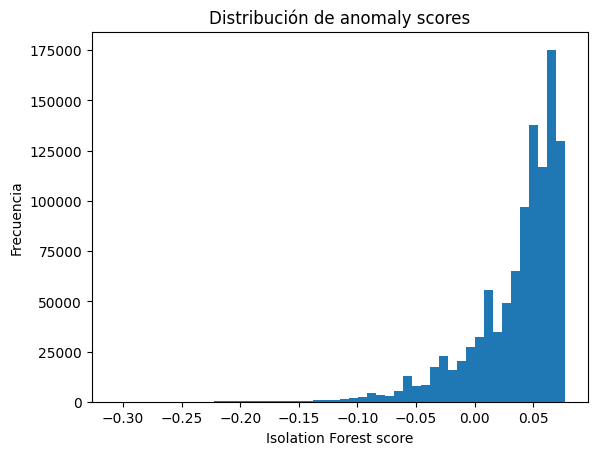

In [89]:
import matplotlib.pyplot as plt

plt.hist(df_master['if_score'], bins=50)
plt.xlabel('Isolation Forest score')
plt.ylabel('Frecuencia')
plt.title('Distribución de anomaly scores')
plt.show()


In [91]:
df_master.to_csv(
    'access_log_master_manual_lab_if_score.csv',
    index=False
)
